In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

### Exp. 1: Global Memory vs Shared Memory

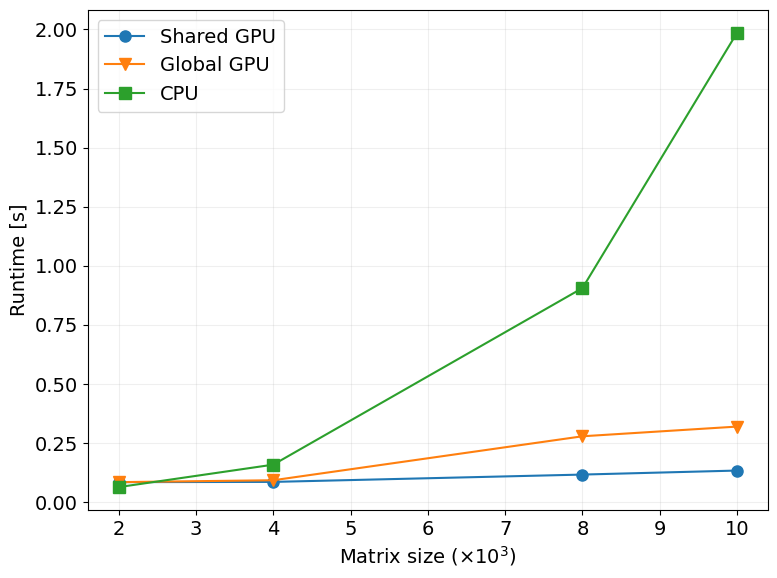

In [2]:
# Matrix sizes
matrix_sizes = np.array([2000, 4000, 8000, 10000]) / 1000

# Runtimes
cpu = np.array([0.064, 0.159, 0.906, 1.986])
# shared_gpu = np.array([0.077, 0.097, 0.135, 0.155])
# global_gpu = np.array([0.083, 0.107, 0.168, 0.203])

shared_gpu = np.array([0.085, 0.086, 0.117, 0.134])
global_gpu = np.array([0.085, 0.093, 0.279, 0.320])


# Plotting results
plt.figure(figsize=(8, 6))
plt.plot(matrix_sizes, shared_gpu, marker='o', linestyle='-', linewidth=1.5, markersize=8, label='Shared GPU')
plt.plot(matrix_sizes, global_gpu, marker='v', linestyle='-', linewidth=1.5, markersize=8, label='Global GPU')
plt.plot(matrix_sizes, cpu, marker='s', linestyle='-', linewidth=1.5, markersize=8, label='CPU')
plt.xlabel(r'Matrix size ($\times 10^3$)')
plt.ylabel('Runtime [s]')
plt.legend()
plt.grid(alpha=.2)
plt.tight_layout()
plt.savefig("./shared_v_global.pdf")
plt.show()

### Exp. 2: Benchmark Runtimes for different matrix and thread block sizes

In [3]:
import re
from pathlib import Path

def parse_step2_results(results_dir="../step_2"):
    """Parse step_2 output files. Returns dict keyed by block size,
    each containing sorted arrays of matrix_sizes, cpu_runtimes, and gpu_runtimes."""
    results = {}
    pattern = re.compile(r"output_s(\d+)_b(\d+)\.out")

    for filepath in Path(results_dir).glob("output_s*_b*.out"):
        match = pattern.match(filepath.name)
        if not match:
            continue
        m_size = int(match.group(1))
        b_size = int(match.group(2))

        text = filepath.read_text()
        cpu_time = float(re.search(r"CPU: run time = ([\d.]+)", text).group(1))
        gpu_time = float(re.search(r"GPU: Total runtime.*= ([\d.]+)", text).group(1))

        if b_size not in results:
            results[b_size] = {"matrix_sizes": [], "cpu": [], "gpu": []}
        results[b_size]["matrix_sizes"].append(m_size)
        results[b_size]["cpu"].append(cpu_time)
        results[b_size]["gpu"].append(gpu_time)

    # Sort by matrix size and convert to arrays
    for b_size in results:
        order = np.argsort(results[b_size]["matrix_sizes"])
        results[b_size]["matrix_sizes"] = np.array(results[b_size]["matrix_sizes"])[order]
        results[b_size]["cpu"] = np.array(results[b_size]["cpu"])[order]
        results[b_size]["gpu"] = np.array(results[b_size]["gpu"])[order]

    return results

results = parse_step2_results()

for b_size in sorted(results):
    print(f"Block size {b_size}: sizes={results[b_size]['matrix_sizes']}, "
          f"cpu={results[b_size]['cpu']}, gpu={results[b_size]['gpu']}")

Block size 32: sizes=[   50   500  2000  4000  8000 10000], cpu=[6.300000e-05 5.069000e-03 6.611300e-02 1.589980e-01 8.908440e-01
 1.999068e+00], gpu=[0.185963 0.079963 0.080049 0.088229 0.142735 0.171034]
Block size 64: sizes=[   50   500  2000  4000  8000 10000], cpu=[6.300000e-05 5.100000e-03 6.371200e-02 1.591390e-01 8.896490e-01
 1.991949e+00], gpu=[0.090867 0.081956 0.081755 0.106317 0.126819 0.151763]
Block size 100: sizes=[   50   500  2000  4000  8000 10000], cpu=[6.500000e-05 5.085000e-03 6.378000e-02 1.590070e-01 9.040830e-01
 2.004403e+00], gpu=[0.097704 0.080546 0.08631  0.093699 0.119183 0.148668]


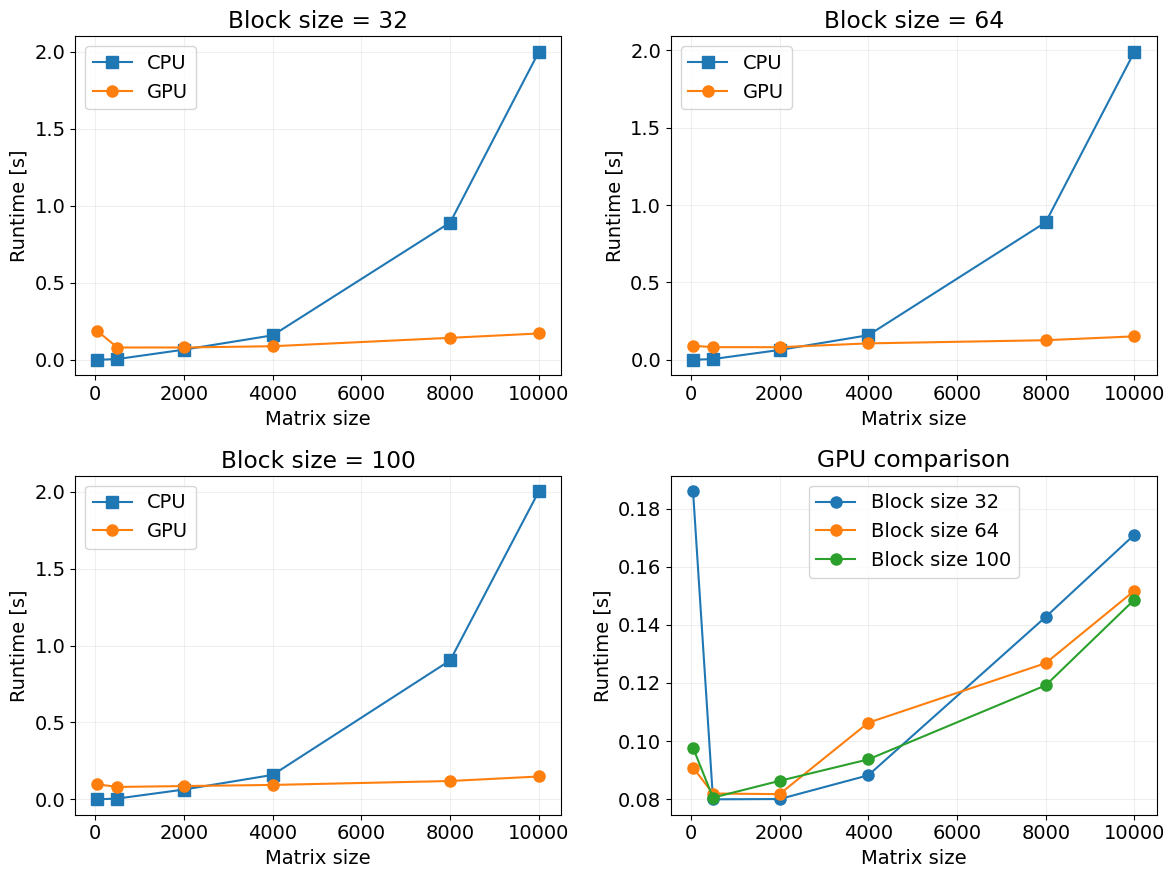

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs = axs.flatten()

block_sizes = sorted(results.keys())

for i, b_size in enumerate(block_sizes):
    ax = axs[i]
    r = results[b_size]
    sizes = r["matrix_sizes"]
    ax.plot(sizes, r["cpu"], marker='s', linestyle='-', linewidth=1.5, markersize=8, label='CPU')
    ax.plot(sizes, r["gpu"], marker='o', linestyle='-', linewidth=1.5, markersize=8, label='GPU')
    ax.set_title(f'Block size = {b_size}')
    ax.set_xlabel(r'Matrix size')
    ax.set_ylabel('Runtime [s]')
    ax.legend()
    ax.grid(alpha=.2)

# 4th subplot: GPU runtime comparison across block sizes
ax = axs[3]
for b_size in block_sizes:
    r = results[b_size]
    sizes = r["matrix_sizes"]
    ax.plot(sizes, r["gpu"], marker='o', linestyle='-', linewidth=1.5, markersize=8, label=f'Block size {b_size}')
ax.set_title('GPU comparison')
ax.set_xlabel(r'Matrix size')
ax.set_ylabel('Runtime [s]')
ax.legend()
ax.grid(alpha=.2)

plt.tight_layout()
plt.savefig("./block_size_benchmark.pdf")
plt.show()

CPU runtime is clearly not relevant here for analysis, since it's the same up to some floating point fluctuations for all block sizes. The main takeaway is the same one as in the first experiment, there's some matrix size threshold where GPU parallelization surpasses the serial CPU implementation of the power method.

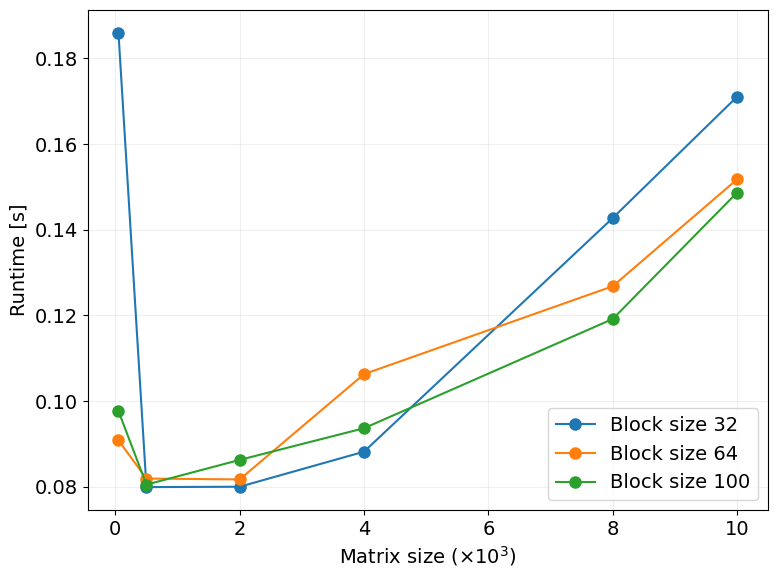

In [5]:
fig = plt.figure(figsize=(8, 6))
for b_size in block_sizes:
    r = results[b_size]
    sizes = r["matrix_sizes"] / 1000
    plt.plot(sizes, r["gpu"], marker='o', linestyle='-', linewidth=1.5, markersize=8, label=f'Block size {b_size}')
plt.xlabel(r"Matrix size ($\times 10^3$)")
plt.ylabel("Runtime [s]")
plt.legend()
plt.grid(alpha=.2)
plt.tight_layout()
plt.savefig("./block_size_benchmark_gpu.pdf")
plt.show()
plt.show()

### Exp. 3 & 4: Calculate speedups with and without memory transfers between CPU and GPU

In [6]:
import re
from pathlib import Path

def parse_step3_results(results_dir="../step_3"):
    """Parse step_3 output files. Returns dict with sorted arrays of
    matrix_sizes, speedup_incl, and speedup_excl."""
    results = {"matrix_sizes": [], "speedup_incl": [], "speedup_excl": []}
    pattern = re.compile(r"output_s(\d+)\.out")

    for filepath in Path(results_dir).glob("output_s*.out"):
        match = pattern.match(filepath.name)
        if not match:
            continue

        m_size = int(match.group(1))
        text = filepath.read_text()
        speedup_incl = float(re.search(r"Speedup \(incl\. Memory copies\) = ([\d.]+)", text).group(1)[:-1])
        speedup_excl = float(re.search(r"Speedup \(excl\. Memory copies\) = ([\d.]+)", text).group(1)[:-1])

        results["matrix_sizes"].append(m_size)
        results["speedup_incl"].append(speedup_incl)
        results["speedup_excl"].append(speedup_excl)

    # Sort by matrix size and convert to arrays
    order = np.argsort(results["matrix_sizes"])
    results["matrix_sizes"] = np.array(results["matrix_sizes"])[order]
    results["speedup_incl"] = np.array(results["speedup_incl"])[order]
    results["speedup_excl"] = np.array(results["speedup_excl"])[order]

    return results

results = parse_step3_results()

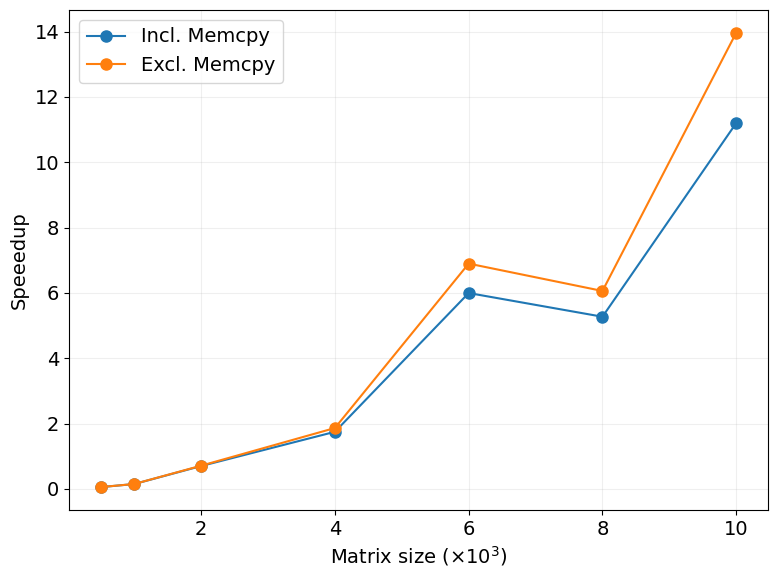

In [7]:
fig = plt.figure(figsize=(8, 6))
sizes = results["matrix_sizes"] / 1000 # type: ignore
plt.plot(sizes, results["speedup_incl"], marker='o', linestyle='-', linewidth=1.5, markersize=8, label=f'Incl. Memcpy')
plt.plot(sizes, results["speedup_excl"], marker='o', linestyle='-', linewidth=1.5, markersize=8, label=f'Excl. Memcpy')
plt.xlabel(r"Matrix size ($\times 10^3$)")
plt.ylabel("Speeedup")
plt.legend()
plt.grid(alpha=.2)
plt.tight_layout()
plt.savefig("./speedup.pdf")
plt.show()
plt.show()